**Overview**

This notebook implements a **visual-only pipeline** for the Fake News Detection project using the **AMG (Attribution Multi-Granularity)** dataset.

It focuses on using visual information alone (without captions) to detect whether an image is likely associated with real or fake news.

The goal of this notebook is to:
- Explore a vision-based approach using a pretrained vision-language model (VLM)
- Add an LLM reasoning layer to evaluate whether multi-step inference improves decisions

This pipeline has two levels of prediction:

1. **Zero-Shot Classification Layer**
The CLIP model (`openai/clip-vit-base-patch32`) compares each image against two textual prompts and outputs:
    - `fake` or `real`
    - confidence score (softmax probability)

2. **LLM Reasoning Layer**
`gpt-4.1-mini` via OpenRouter takes the CLIP zero-shot outputs + Top-K visual concepts derived from the image, and returns:
    - Decision (Fake / Real)
    - Short explanation
    - Nudge (user-facing actionable advice)

**AMG Label Schema**
- `0` → Real News → binary **1** (Real)
- `1` → Image Fabrication → binary **0** (Fake)
- `2` → Entity Inconsistency → binary **0** (Fake)
- `3` → Event Inconsistency → binary **0** (Fake)
- `4` → Time & Space Inconsistency → binary **0** (Fake)
- `5` → Ineffective Visual Information → binary **0** (Fake)

This notebook is one of the early pipelines developed as part of the project before building the multimodal agentic system.

## 1. Setup Dependencies

In this section we import all required libraries and initialize the main resources used throughout the notebook.

This includes:
- CLIP (from HuggingFace `transformers`) for image feature extraction and zero-shot classification
- PIL for image loading
- OpenRouter, accessed through the OpenAI-compatible client, for the reasoning layer
- scikit-learn, matplotlib, and seaborn for evaluation and visualization

We also define the main configuration variables such as:
- the dataset split to use (`train`, `val`, or `test`)
- the maximum number of rows to sample
- the CLIP model name
- the OpenRouter model name
- the number of Top-K visual concepts to extract per image

Finally, we load the API key from the `.env` file.

In [1]:
# ============================================================
# VISUAL-ONLY FAKE NEWS PIPELINE — AMG Dataset
# Structure:
# 1) Setup dependencies
# 2) Dataset loading
# 3) Visual concepts (CLIP + ImageNet + Places365)
# 4) Zero-shot CLIP classification
# 5) OpenRouter LLM reasoning layer
# 6) Evaluation
# 7) Dataset inspection
# ============================================================

# ============================================================
# 1. SETUP DEPENDENCIES
# ============================================================

import os
import re
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path
from numpy.linalg import norm
from PIL import Image, ImageFile
from tqdm import tqdm
from dotenv import load_dotenv
from transformers import CLIPProcessor, CLIPModel
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from torchvision.datasets.utils import download_url
from openai import OpenAI

# Allow PIL to load truncated/corrupted image files without raising an error
ImageFile.LOAD_TRUNCATED_IMAGES = True

print("--- [1] Setup complete ---")

# ---------------- CONFIG ----------------
# Paths (relative to this notebook inside Early Pipelines/)
AMG_DATASET_DIR = Path("../Datasets")
AMG_SPLIT       = "test"   # "train", "val", or "test"

MAX_ROWS     = 200   # set None to use all matched images
RANDOM_STATE = 42
TOP_K        = 5     # number of visual concepts per image

CLIP_MODEL_NAME  = "openai/clip-vit-base-patch32"
OPENROUTER_MODEL = "openai/gpt-4.1-mini"

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load .env one level up
load_dotenv(dotenv_path=Path("../.env"))
openrouter_api_key = os.getenv("OPENROUTER_API_KEY")
if not openrouter_api_key:
    raise ValueError(
        "Missing OPENROUTER_API_KEY environment variable. "
        "Set it in the .env file before running."
    )

client = OpenAI(
    api_key=openrouter_api_key,
    base_url="https://openrouter.ai/api/v1"
)

c:\Users\anapa\anaconda3\envs\FakeNewsAP\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- [1] Setup complete ---
Using device: cpu


## 2. Dataset Loading

Here we load the **AMG** annotation file and match each entry to its corresponding image file in `Datasets/AMG_MEDIA/{split}/`.

Only entries for which a `.jpg` file exists are kept — this is the effective working set for the visual pipeline.

The binary label mapping applied is:
- `0` (Real News) → **1** (Real)
- `1–5` (any fake type) → **0** (Fake)

We then optionally sample 200 rows with a fixed random seed.

In [2]:
# ============================================================
# 2. DATASET LOADING (AMG — images matched by Id)
# ============================================================

print("--- [2] Dataset loading: AMG visual ---")

AMG_LABEL_NAMES = {
    0: "real_news",
    1: "image_fabrication",
    2: "entity_inconsistency",
    3: "event_inconsistency",
    4: "time_space_inconsistency",
    5: "ineffective_visual_information",
}


def amg_label_name(x):
    try:
        return AMG_LABEL_NAMES.get(int(x), "unknown")
    except Exception:
        return "unknown"


def normalize_label_amg(label_value):
    """
    Binary mapping:
      0        -> 1  (Real)
      1,2,3,4,5 -> 0  (Fake)
    """
    try:
        x = int(label_value)
    except Exception:
        return None
    if x == 0:
        return 1
    if x in {1, 2, 3, 4, 5}:
        return 0
    return None


# Load annotation JSON
json_path = AMG_DATASET_DIR / f"{AMG_SPLIT}.json"
img_dir   = AMG_DATASET_DIR / "AMG_MEDIA" / AMG_SPLIT

if not json_path.exists():
    raise FileNotFoundError(f"Annotation file not found: {json_path}")
if not img_dir.exists():
    raise FileNotFoundError(f"Image directory not found: {img_dir}")

with open(json_path, encoding="utf-8") as f:
    raw_data = json.load(f)

# Build a set of available image stems (Id without extension)
available_ids = {p.stem for p in img_dir.glob("*.jpg")}
print(f"\nImages available in {AMG_SPLIT}/: {len(available_ids)}")
print(f"Annotation entries in {AMG_SPLIT}.json: {len(raw_data)}")

# Keep only entries with a matching image
matched = [
    {
        "orig_id"    : row["Id"],
        "image_path" : str(img_dir / f"{row['Id']}.jpg"),
        "label_raw"  : row["label"],
        "label_name" : amg_label_name(row["label"]),
        "label"      : normalize_label_amg(row["label"]),
    }
    for row in raw_data
    if str(row["Id"]) in available_ids and normalize_label_amg(row["label"]) is not None
]

print(f"Matched entries (annotation + image): {len(matched)}")

# Show original AMG label breakdown before sampling
full_df = pd.DataFrame(matched)
print(f"\nOriginal AMG label counts (matched {AMG_SPLIT} set):")
raw_counts = pd.to_numeric(full_df["label_raw"], errors="coerce").dropna().astype(int).value_counts().sort_index()
for lbl, cnt in raw_counts.items():
    print(f"  {lbl} = {amg_label_name(lbl):<32s} -> {cnt}")

# Optional sample
if MAX_ROWS is not None:
    image_df = full_df.sample(min(MAX_ROWS, len(full_df)), random_state=RANDOM_STATE).reset_index(drop=True)
else:
    image_df = full_df.reset_index(drop=True)

print(f"\nRows used after sampling : {len(image_df)}")
print("\nBinary label distribution (sample):")
print(image_df["label"].value_counts().sort_index())   # 0=Fake, 1=Real

--- [2] Dataset loading: AMG visual ---

Images available in test/: 427
Annotation entries in test.json: 979
Matched entries (annotation + image): 427

Original AMG label counts (matched test set):
  0 = real_news                        -> 386
  1 = image_fabrication                -> 5
  2 = entity_inconsistency             -> 15
  3 = event_inconsistency              -> 11
  4 = time_space_inconsistency         -> 5
  5 = ineffective_visual_information   -> 5

Rows used after sampling : 200

Binary label distribution (sample):
label
0     21
1    179
Name: count, dtype: int64


In [3]:
# Preview the first few rows and a sample image
pd.set_option('display.max_colwidth', None)
image_df[["orig_id", "image_path", "label_name", "label"]].head(10)

,orig_id,image_path,label_name,label
0,5028,..\Datasets\AMG_MEDIA\test\5028.jpg,real_news,1
1,4134,..\Datasets\AMG_MEDIA\test\4134.jpg,real_news,1
2,4295,..\Datasets\AMG_MEDIA\test\4295.jpg,real_news,1
3,4088,..\Datasets\AMG_MEDIA\test\4088.jpg,real_news,1
4,4709,..\Datasets\AMG_MEDIA\test\4709.jpg,entity_inconsistency,0
5,4391,..\Datasets\AMG_MEDIA\test\4391.jpg,real_news,1
6,4273,..\Datasets\AMG_MEDIA\test\4273.jpg,real_news,1
7,4270,..\Datasets\AMG_MEDIA\test\4270.jpg,real_news,1
8,4283,..\Datasets\AMG_MEDIA\test\4283.jpg,real_news,1
9,4293,..\Datasets\AMG_MEDIA\test\4293.jpg,real_news,1


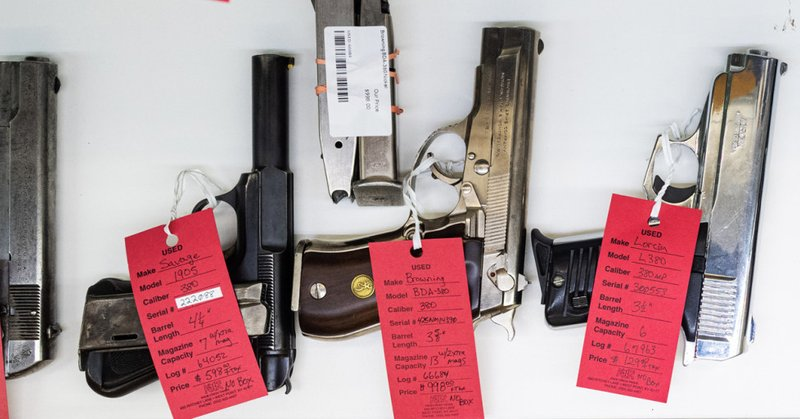

In [4]:
# Display a sample image to confirm loading works
Image.open(image_df["image_path"].iloc[0])

## 3. Visual Concepts (CLIP + ImageNet + Places365)

In this section we load CLIP and build a vocabulary of visual concepts from:
- **ImageNet-1K** (1 000 object categories)
- **Places365** (365 scene/location categories)

For every image we:
1. Extract a CLIP image embedding (512-dim vector)
2. Compute cosine similarity against all concept text embeddings
3. Return the Top-K highest-scoring concepts

These visual concepts serve as the semantic signal passed to the LLM reasoning layer — playing the same role that VADER + NER entities play in the text agent.

In [5]:
# ============================================================
# 3. VISUAL CONCEPTS  (CLIP + ImageNet + Places365)
# ============================================================

print("--- [3] Loading CLIP model ---")

clip_model     = CLIPModel.from_pretrained(CLIP_MODEL_NAME)
clip_processor = CLIPProcessor.from_pretrained(CLIP_MODEL_NAME)
clip_model.to(device)
clip_model.eval()
print("CLIP model loaded.")

--- [3] Loading CLIP model ---


Loading weights: 100%|██████████| 398/398 [00:00<00:00, 1145.58it/s, Materializing param=visual_projection.weight]                                
CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


CLIP model loaded.


In [6]:
# ---- Image embedding ----
def get_image_embedding(image_path: str):
    """
    Extracts a CLIP vision embedding from an RGB image.
    Returns a NumPy vector of shape (512,).
    """
    image  = Image.open(image_path).convert("RGB")
    inputs = clip_processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        img_emb = clip_model.get_image_features(**inputs)
    # Newer transformers may return a model output object instead of a tensor
    if hasattr(img_emb, "pooler_output"):
        img_emb = img_emb.pooler_output
    return img_emb.squeeze().cpu().numpy()


# ---- Text embedding ----
def get_text_embedding(text_list):
    """
    Encodes a list of text labels using the CLIP text encoder.
    Returns a NumPy matrix of shape (N_texts, 512).
    """
    inputs = clip_processor(
        text=text_list, return_tensors="pt", padding=True, truncation=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        text_emb = clip_model.get_text_features(**inputs)
    # Newer transformers may return a model output object instead of a tensor
    if hasattr(text_emb, "pooler_output"):
        text_emb = text_emb.pooler_output
    return text_emb.cpu().numpy()

In [7]:
# ---- Download ImageNet-1K class names ----
url_imagenet = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
download_url(url_imagenet, ".", "imagenet_classes.txt")

with open("imagenet_classes.txt", "r") as f:
    imagenet_labels = [line.strip() for line in f.readlines()]

print("ImageNet classes loaded:", len(imagenet_labels))

ImageNet classes loaded: 1000


In [8]:
# ---- Download Places365 category file ----
url_places = "https://raw.githubusercontent.com/csailvision/places365/master/categories_places365.txt"
download_url(url_places, ".", "places365.txt")

places365_labels = []
with open("places365.txt", "r") as f:
    for line in f:
        raw_label = line.split()[0]          # e.g. "/a/airfield"
        label     = raw_label.split("/", 2)[-1]  # e.g. "airfield"
        label     = label.replace("_", " ").replace("/", " ")
        places365_labels.append(label)

print("Places365 classes loaded:", len(places365_labels))

# ---- Combine concept vocabulary ----
concepts = imagenet_labels + places365_labels
print("Total visual concepts:", len(concepts))

Places365 classes loaded: 365
Total visual concepts: 1365


In [9]:
# ---- Compute CLIP text embeddings for all concepts ----
# Process in batches to avoid OOM on the concept matrix
BATCH_SIZE = 256
concept_emb_list = []

for i in tqdm(range(0, len(concepts), BATCH_SIZE), desc="Encoding concepts"):
    batch = concepts[i : i + BATCH_SIZE]
    concept_emb_list.append(get_text_embedding(batch))

concept_embs = np.vstack(concept_emb_list)
print("Concept embedding matrix shape:", concept_embs.shape)

Encoding concepts: 100%|██████████| 6/6 [00:02<00:00,  2.18it/s]

Concept embedding matrix shape: (1365, 512)


In [10]:
# ---- Compute CLIP image embeddings for all samples ----
image_paths = image_df["image_path"].tolist()

img_embeddings = np.vstack([
    get_image_embedding(p)
    for p in tqdm(image_paths, desc="Encoding images")
])
print("Image embedding matrix shape:", img_embeddings.shape)

Encoding images: 100%|██████████| 200/200 [00:11<00:00, 16.94it/s]

Image embedding matrix shape: (200, 512)


In [11]:
# ---- Top-K concept extraction ----
def get_top_k_labels(image_emb, k=TOP_K):
    """
    Returns the top-k (concept, cosine_similarity) pairs for a given image embedding.
    """
    image_emb_norm   = image_emb / norm(image_emb)
    concept_mags     = norm(concept_embs, axis=1)
    concept_embs_norm = concept_embs / concept_mags[:, np.newaxis]
    sims             = concept_embs_norm @ image_emb_norm
    topk_idx         = sims.argsort()[::-1][:k]
    return [(concepts[i], float(sims[i])) for i in topk_idx]


# Quick test with the first image
print("Top-5 concepts for first image:")
print(get_top_k_labels(img_embeddings[0], k=5))

Top-5 concepts for first image:
[('holster', 0.2335595041513443), ('slide rule', 0.2286383956670761), ('combination lock', 0.2273542433977127), ('rifle', 0.22595886886119843), ('assault rifle', 0.22533948719501495)]


## 4. Zero-Shot CLIP Classification

We predict whether each image is real or fake by computing CLIP's zero-shot similarity between the image embedding and two predefined textual prompts.

The label prompts used are:
- `"a staged or manipulated fake news photo"` → Fake
- `"a real photo from a legitimate news report"` → Real

The softmax probability over these two prompts gives the zero-shot confidence.

In [12]:
# ============================================================
# 4. ZERO-SHOT CLIP CLASSIFICATION
# ============================================================

print("--- [4] Zero-shot CLIP classification ---")

# Label prompts — same as Visual_Only reference
LABEL_PROMPTS = [
    "a staged or manipulated fake news photo",   # index 0 -> fake
    "a real photo from a legitimate news report" # index 1 -> real
]


def clip_zero_shot(image_path):
    """
    Returns:
      pred_label  : 'fake' or 'real'
      confidence  : softmax probability of the top prediction
    """
    image  = Image.open(image_path).convert("RGB")
    inputs = clip_processor(
        text=LABEL_PROMPTS, images=image,
        return_tensors="pt", padding=True
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = clip_model(**inputs)

    probs    = outputs.logits_per_image.softmax(dim=1)[0].cpu().numpy()
    pred_idx = int(np.argmax(probs))
    label    = "real" if pred_idx == 1 else "fake"
    return label, float(probs[pred_idx])


# Run zero-shot classification on all samples
zs_results = [
    clip_zero_shot(p)
    for p in tqdm(image_df["image_path"], desc="CLIP zero-shot")
]

image_df["zs_prediction"] = [r[0] for r in zs_results]
image_df["zs_confidence"] = [r[1] for r in zs_results]

print("\nZero-shot prediction distribution:")
print(image_df["zs_prediction"].value_counts())

--- [4] Zero-shot CLIP classification ---


CLIP zero-shot: 100%|██████████| 200/200 [00:13<00:00, 15.22it/s]


Zero-shot prediction distribution:
zs_prediction
real    142
fake     58
Name: count, dtype: int64


## 5. OpenRouter LLM Reasoning Layer

In this section, we use `gpt-4.1-mini` via **OpenRouter** to interpret the visual evidence produced so far.

The LLM receives:
- the Top-K visual concepts extracted from the image (with cosine similarity scores)
- the zero-shot CLIP prediction and its confidence

The prompt explicitly tells the LLM to:
- treat the CLIP classifier output as the primary signal
- use the visual concepts as supporting semantic context
- produce a single binary decision: Real or Fake

This section produces:
- the raw LLM response
- the parsed decision (`Real` / `Fake`)
- the explanation
- the nudge (verification suggestion)

In [13]:
# ============================================================
# 5. OPENROUTER LLM REASONING LAYER
# ============================================================

print("--- [5] OpenRouter LLM reasoning layer ---")


def build_visual_prompt(topk, pred_label, conf):
    features  = "\n".join([f'- "{c}" ({s:.2f})' for c, s in topk])
    pred_word = "Real" if pred_label == "real" else "Fake"

    return f"""You are a misinformation detection assistant.

Visual features extracted from the image:
{features}

A visual classifier predicted that the image is likely: {pred_word}
Classifier confidence: {conf:.2f}

Please:
1. Decide if this image is likely associated with real or fake news. Choose ONE of: Real / Fake
2. Provide a SHORT explanation (1–2 sentences).
3. Suggest ONE action the user can take to verify.

Respond EXACTLY in this format:
- Decision: Real or Fake
- Explanation: your explanation here
- Nudge: your suggestion here
""".strip()


def query_openrouter(prompt, model=OPENROUTER_MODEL, max_retries=3):
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=model,
                temperature=0,
                max_tokens=150,
                messages=[
                    {
                        "role": "system",
                        "content": (
                            "You are an independent misinformation detection assistant. "
                            "Provide concise, structured outputs."
                        )
                    },
                    {
                        "role": "user",
                        "content": prompt
                    }
                ]
            )
            return response.choices[0].message.content.strip()
        except Exception as e:
            print("OpenRouter API error:", repr(e))
            if attempt == max_retries - 1:
                return f"- Decision: Error\n- Explanation: API failed: {str(e)}\n- Nudge: None"
            time.sleep(2)


def parse_field(resp, key):
    m = re.search(rf"-\s*{key}\s*:\s*(.*)", str(resp), flags=re.IGNORECASE)
    return m.group(1).strip() if m else ""


# --- Quick single test before full loop ---
test_topk  = get_top_k_labels(img_embeddings[0])
test_pred  = image_df.iloc[0]["zs_prediction"]
test_conf  = image_df.iloc[0]["zs_confidence"]
test_prompt = build_visual_prompt(test_topk, test_pred, test_conf)

print("\n--- OpenRouter test call ---")
print(query_openrouter(test_prompt))


# --- Main execution loop ---
results = []

for i, row in tqdm(image_df.iterrows(), total=len(image_df), desc="Running Visual Agent (AMG)"):
    topk   = get_top_k_labels(img_embeddings[i])
    prompt = build_visual_prompt(topk, row["zs_prediction"], row["zs_confidence"])
    llm_out = query_openrouter(prompt)

    results.append({
        "orig_id"       : row["orig_id"],
        "image_path"    : row["image_path"],
        "label_name"    : row["label_name"],
        "true_label"    : row["label"],
        "topk_features" : topk,
        "zs_prediction" : row["zs_prediction"],
        "zs_confidence" : row["zs_confidence"],
        "llm_response"  : llm_out,
    })

results_df = pd.DataFrame(results)

# Parse LLM fields
results_df["llm_decision"]    = results_df["llm_response"].apply(lambda r: parse_field(r, "Decision"))
results_df["llm_explanation"] = results_df["llm_response"].apply(lambda r: parse_field(r, "Explanation"))
results_df["llm_nudge"]       = results_df["llm_response"].apply(lambda r: parse_field(r, "Nudge"))

print("\n--- LLM decision distribution ---")
print(results_df["llm_decision"].value_counts(dropna=False))

--- [5] OpenRouter LLM reasoning layer ---

--- OpenRouter test call ---
- Decision: Real  
- Explanation: The image contains identifiable objects like a rifle, holster, and combination lock, which are consistent with real-world items, and the classifier confidence supports authenticity.  
- Nudge: Check the image source and cross-reference with reputable news outlets or official reports to confirm the context.


Running Visual Agent (AMG): 100%|██████████| 200/200 [07:15<00:00,  2.18s/it]


--- LLM decision distribution ---
llm_decision
Fake    101
Real     99
Name: count, dtype: int64


In [14]:
# Display the full results table
results_df[[
    "orig_id", "true_label", "label_name",
    "topk_features", "zs_prediction", "zs_confidence",
    "llm_decision", "llm_explanation", "llm_nudge"
]]

,orig_id,true_label,label_name,topk_features,zs_prediction,zs_confidence,llm_decision,llm_explanation,llm_nudge
0,5028,1,real_news,"[(holster, 0.2335595041513443), (slide rule, 0.2286383956670761), (combination lock, 0.2273542433977127), (rifle, 0.22595886886119843), (assault rifle, 0.22533948719501495)]",real,0.682851,Real,"The image contains identifiable objects like a rifle, holster, and combination lock, which are consistent with real-world items, and the classifier confidence supports authenticity.",Check the image source and cross-reference with reputable news outlets or official reports to confirm the context.
1,4134,1,real_news,"[(mailbag, 0.23181778192520142), (nematode, 0.2306331992149353), (book jacket, 0.22437752783298492), (sunglasses, 0.22057607769966125), (wig, 0.22028958797454834)]",real,0.936594,Real,"The image classifier shows high confidence that the image is real, and the detected objects (mailbag, nematode, book jacket, sunglasses, wig) do not inherently suggest manipulation or misinformation.",Check the original source or context where the image was published to confirm its authenticity and relevance.
2,4295,1,real_news,"[(partridge, 0.2529540956020355), (hippopotamus, 0.2525613307952881), (hen, 0.2504233717918396), (cockroach, 0.25020620226860046), (bib, 0.2464117556810379)]",real,0.827877,Real,"The image classifier identifies common animals and objects with high confidence, suggesting the image content is genuine and not manipulated.",Check the image source or reverse image search to confirm its origin and context.
3,4088,1,real_news,"[(book jacket, 0.2293151617050171), (cock, 0.22829066216945648), (admiral, 0.22675739228725433), (bazaar outdoor, 0.22587843239307404), (corral, 0.2241506576538086)]",fake,0.643166,Fake,"The image features unrelated and inconsistent elements like ""cock,"" ""admiral,"" and ""bazaar outdoor,"" which suggest it may be manipulated or misrepresented. The classifier's moderate confidence also indicates potential misinformation.",Check the image source and cross-reference with trusted news outlets to confirm its authenticity.
4,4709,0,entity_inconsistency,"[(buckeye, 0.21544818580150604), (mailbag, 0.20841047167778015), (badger, 0.20514608919620514), (field wild, 0.20514026284217834), (stadium football, 0.20376819372177124)]",real,0.724132,Real,"The image contains recognizable and contextually consistent elements related to college football teams and stadiums, which aligns with real sports event coverage. The classifier's confidence also supports the image's authenticity.",Check the image against official sports team websites or trusted sports news sources to confirm the event and location.
...,...,...,...,...,...,...,...,...,...
195,4153,1,real_news,"[(chimpanzee, 0.22780291736125946), (maillot, 0.22611723840236664), (maillot, 0.22611723840236664), (bolo tie, 0.22541150450706482), (suit, 0.2242249697446823)]",real,0.558053,Fake,"The image likely depicts a chimpanzee dressed in human clothing, which is unusual and often used in manipulated or staged content to create humorous or misleading narratives. The low classifier confidence also suggests uncertainty about authenticity.",Search for the image using reverse image search tools to check its origin and context.
196,4127,1,real_news,"[(eft, 0.23546288907527924), (screwdriver, 0.2294960469007492), (army base, 0.22732794284820557), (cock, 0.22462016344070435), (stretcher, 0.22170095145702362)]",real,0.975251,Real,"The image features common, plausible elements such as a screwdriver, stretcher, and army base, and the classifier shows high confidence in its authenticity. These details suggest it is likely a genuine photo rather than fabricated.",Check for credible news sources or official statements that corroborate the context or event depicted in the image.
197,4347,1,real_news,"[(pirate, 0.24624130129814148), (ocean, 0.24356941878795624), (scuba diver, 0.24287515878677368), (raft, 0.24119433760643005), (lifeboat, 0.239835098385810

## 6. Evaluation

This section compares the performance of:
- the **Zero-Shot CLIP** classifier
- the **LLM-enhanced** visual agent

We compute:
- accuracy
- LLM coverage
- confusion matrices
- classification reports

The goal is to determine whether the LLM reasoning layer improves over the zero-shot visual classifier alone.

In [15]:
# ============================================================
# 6. EVALUATION
# ============================================================

print("--- [6] Evaluation ---")


def label_to_int(x):
    x = str(x).strip().lower()
    if x == "fake": return 0
    if x == "real": return 1
    return None


results_df["true_label"] = results_df["true_label"].astype(int)
results_df["zs_label"]   = results_df["zs_prediction"].apply(label_to_int)
results_df["llm_label"]  = results_df["llm_decision"].apply(label_to_int)

# Drop rows where LLM gave invalid/unparseable output
llm_clean = results_df.dropna(subset=["llm_label"]).copy()
llm_clean["llm_label"] = llm_clean["llm_label"].astype(int)

# Accuracies
zs_acc  = accuracy_score(results_df["true_label"], results_df["zs_label"])
llm_acc = accuracy_score(llm_clean["true_label"],  llm_clean["llm_label"]) if len(llm_clean) > 0 else float("nan")
llm_cov = len(llm_clean) / len(results_df) if len(results_df) > 0 else 0.0

print(f"Zero-Shot CLIP Accuracy : {zs_acc:.3f}")
print(f"LLM Accuracy            : {llm_acc:.3f}" if len(llm_clean) > 0 else "LLM Accuracy: nan")
print(f"LLM Coverage            : {llm_cov:.3f}")

# Confusion matrices
zs_cm  = confusion_matrix(results_df["true_label"], results_df["zs_label"])
print("\nZero-Shot CLIP Confusion Matrix:\n", zs_cm)

if len(llm_clean) > 0:
    llm_cm = confusion_matrix(llm_clean["true_label"], llm_clean["llm_label"])
    print("\nLLM Confusion Matrix:\n", llm_cm)

# Classification reports
print("\n-----------------------------------------------------")
print("Zero-Shot CLIP Classification Report")
print("-----------------------------------------------------")
print(classification_report(results_df["true_label"], results_df["zs_label"], target_names=["Fake", "Real"]))

if len(llm_clean) > 0:
    print("\n-----------------------------------------------------")
    print("LLM Classification Report")
    print("-----------------------------------------------------")
    print(classification_report(llm_clean["true_label"], llm_clean["llm_label"], target_names=["Fake", "Real"]))

--- [6] Evaluation ---
Zero-Shot CLIP Accuracy : 0.695
LLM Accuracy            : 0.510
LLM Coverage            : 1.000

Zero-Shot CLIP Confusion Matrix:
 [[  9  12]
 [ 49 130]]

LLM Confusion Matrix:
 [[12  9]
 [89 90]]

-----------------------------------------------------
Zero-Shot CLIP Classification Report
-----------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.16      0.43      0.23        21
        Real       0.92      0.73      0.81       179

    accuracy                           0.69       200
   macro avg       0.54      0.58      0.52       200
weighted avg       0.84      0.69      0.75       200


-----------------------------------------------------
LLM Classification Report
-----------------------------------------------------
              precision    recall  f1-score   support

        Fake       0.12      0.57      0.20        21
        Real       0.91      0.50      0.65       179

    accu

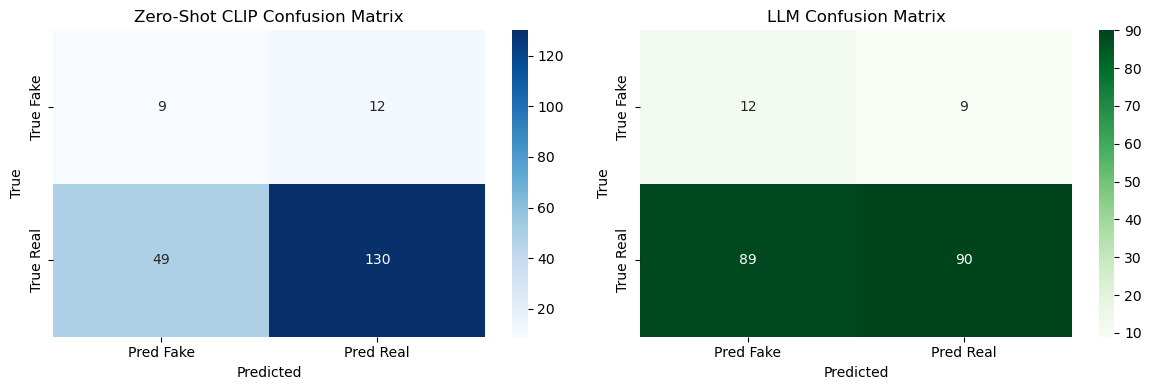

>>> Visual-only pipeline (AMG) complete.


In [16]:
# Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(
    zs_cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Pred Fake", "Pred Real"],
    yticklabels=["True Fake", "True Real"],
    ax=axes[0]
)
axes[0].set_title("Zero-Shot CLIP Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

if len(llm_clean) > 0:
    sns.heatmap(
        llm_cm, annot=True, fmt="d", cmap="Greens",
        xticklabels=["Pred Fake", "Pred Real"],
        yticklabels=["True Fake", "True Real"],
        ax=axes[1]
    )
    axes[1].set_title("LLM Confusion Matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
else:
    axes[1].axis("off")
    axes[1].set_title("LLM Confusion Matrix unavailable")

plt.tight_layout()
plt.show()

print(">>> Visual-only pipeline (AMG) complete.")

## 7. Dataset Inspection + Example Rows

After running the main pipeline, this section inspects the processed dataset.

We print:
- the dataframe shape and columns
- the label distribution (original AMG types + binary)
- missing-value counts

We also break the results into three groups for error analysis:
1. CLIP correct, LLM wrong
2. CLIP wrong, LLM correct
3. Both wrong

In [17]:
# ============================================================
# 7. DATASET INSPECTION + ERROR ANALYSIS
# ============================================================

print("--- Dataset quick inspection ---")
print("Shape:", results_df.shape)
print("\nColumns:", results_df.columns.tolist())

print("\nOriginal AMG label breakdown (sample):")
print(results_df["label_name"].value_counts())

print("\nBinary label distribution:")
print(results_df["true_label"].value_counts().sort_index())   # 0=Fake, 1=Real

print("\nMissing values per column:")
print(results_df.isnull().sum())

--- Dataset quick inspection ---
Shape: (200, 13)

Columns: ['orig_id', 'image_path', 'label_name', 'true_label', 'topk_features', 'zs_prediction', 'zs_confidence', 'llm_response', 'llm_decision', 'llm_explanation', 'llm_nudge', 'zs_label', 'llm_label']

Original AMG label breakdown (sample):
label_name
real_news                         179
entity_inconsistency                9
event_inconsistency                 4
time_space_inconsistency            3
image_fabrication                   3
ineffective_visual_information      2
Name: count, dtype: int64

Binary label distribution:
true_label
0     21
1    179
Name: count, dtype: int64

Missing values per column:
orig_id            0
image_path         0
label_name         0
true_label         0
topk_features      0
zs_prediction      0
zs_confidence      0
llm_response       0
llm_decision       0
llm_explanation    0
llm_nudge          0
zs_label           0
llm_label          0
dtype: int64


In [18]:
# Error analysis
case1 = results_df[(results_df["zs_label"] == results_df["true_label"]) & (results_df["llm_label"] != results_df["true_label"])]
case2 = results_df[(results_df["zs_label"] != results_df["true_label"]) & (results_df["llm_label"] == results_df["true_label"])]
case3 = results_df[(results_df["zs_label"] != results_df["true_label"]) & (results_df["llm_label"] != results_df["true_label"])]

for name, df_case in [("CLIP correct, LLM wrong", case1),
                      ("CLIP wrong, LLM correct", case2),
                      ("Both wrong",              case3)]:
    print(f"\n===== {name} ({len(df_case)} rows) =====")
    for i, (_, row) in enumerate(df_case.head(3).iterrows(), 1):
        print(f"\nExample {i}")
        print("-" * 70)
        print("Image      :", row["image_path"])
        print("True label :", row["true_label"], "(", row["label_name"], ")")
        print("CLIP       :", row["zs_prediction"], "| conf:", round(row["zs_confidence"], 3))
        print("LLM        :", row["llm_decision"])
        print("Top feats  :", [(c, round(s, 3)) for c, s in row["topk_features"]])
        print("Explanation:", row["llm_explanation"])


===== CLIP correct, LLM wrong (40 rows) =====

Example 1
----------------------------------------------------------------------
Image      : ..\Datasets\AMG_MEDIA\test\4391.jpg
True label : 1 ( real_news )
CLIP       : real | conf: 0.766
LLM        : Fake
Top feats  : [('horizontal bar', 0.219), ('American chameleon', 0.219), ('mailbag', 0.214), ('thatch', 0.211), ('bobsled', 0.205)]
Explanation: The extracted visual features (e.g., "American chameleon," "mailbag," "bobsled") are unrelated and nonsensical when combined, suggesting the image content or context may be manipulated or misrepresented.

Example 2
----------------------------------------------------------------------
Image      : ..\Datasets\AMG_MEDIA\test\4131.jpg
True label : 1 ( real_news )
CLIP       : real | conf: 0.973
LLM        : Fake
Top feats  : [('military uniform', 0.218), ('orangutan', 0.216), ('kit fox', 0.215), ('embassy', 0.214), ('army base', 0.209)]
Explanation: The image likely depicts an orangutan in a mi

In [19]:
# False positives: actually Fake, predicted Real by LLM
llm_fp = results_df[
    (results_df["true_label"] == 0) &
    (results_df["llm_label"]  == 1)
]
print(f"LLM false positives (Fake predicted as Real): {len(llm_fp)}")
print(llm_fp[["orig_id", "label_name", "true_label", "llm_label", "llm_explanation"]].head(10).to_string())

LLM false positives (Fake predicted as Real): 9
    orig_id                      label_name  true_label  llm_label                                                                                                                                                                                                                                        llm_explanation
4      4709            entity_inconsistency           0          1                 The image contains recognizable and contextually consistent elements related to college football teams and stadiums, which aligns with real sports event coverage. The classifier's confidence also supports the image's authenticity.
16     4600            entity_inconsistency           0          1  The image contains plausible and contextually consistent elements such as a bolo tie, wig, and mailbag, which align with real-world scenarios rather than fabricated content. The classifier's relatively high confidence also supports authenticity.
27     495

The visual LLM underperformed because it did not receive the raw image or the full CLIP embedding, only a reduced summary of generic visual concepts. This caused substantial information loss, making the LLM less effective than zero shot CLIP for visual fake news classification.